<a href="https://colab.research.google.com/github/hyunsoooo1103/KHUDA_Vacation_Session/blob/main/1%EC%B0%A8%EC%8B%9C_Olist_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brazilian E-Commerce by Olist 🛒 - 데이터 분석 & 예측 모델링 프로젝트

이 프로젝트는 브라질 전자상거래 플랫폼 Olist의 데이터에 대해 탐색적 데이터 분석(EDA)을 수행하고, 비즈니스 성과에 영향을 주는 주요 요인을 파악하는 것을 목표로 합니다. 통계적 인사이트와 비즈니스 관점의 결론을 함께 도출합니다.


## 🎯 비즈니스 문제

- *Olist는 여러 판매자와 브라질 전역의 고객을 연결하는 온라인 마켓플레이스입니다.*
- *이 회사는 배송 지연이라는 문제에 직면해 있습니다.*
- *배송이 늦어지면 고객 만족도와 리뷰 점수가 떨어지며, 결국 이탈률이 높아집니다. 심지어 전반적인 매출과 브랜드 평판에 타격을 줄 수도 있습니다.*
- ***Olist는 어떻게 이 문제를 해결하고 고객의 신뢰를 회복할 수 있을까요?***


# 1️⃣ Importing Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2️⃣ Loading Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/olist_data'

df_customer = pd.read_csv(f'{BASE_PATH}/olist_customers_dataset.csv')
df_location = pd.read_csv(f'{BASE_PATH}/olist_geolocation_dataset.csv')
df_order_items = pd.read_csv(f'{BASE_PATH}/olist_order_items_dataset.csv')
df_order_payment = pd.read_csv(f'{BASE_PATH}/olist_order_payments_dataset.csv')
df_order_review = pd.read_csv(f'{BASE_PATH}/olist_order_reviews_dataset.csv')
df_orders = pd.read_csv(f'{BASE_PATH}/olist_orders_dataset.csv')
df_products = pd.read_csv(f'{BASE_PATH}/olist_products_dataset.csv')
df_translation = pd.read_csv(f'{BASE_PATH}/product_category_name_translation.csv')
df_sellers = pd.read_csv(f'{BASE_PATH}/olist_sellers_dataset.csv')

Mounted at /content/drive


# 3️⃣ Data Clean



### 3.1 Customer Dataset

In [ ]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
df_customer.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


/tmp/ipykernel_512/1912939728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_customer['customer_state'].value_counts().head(10).index,


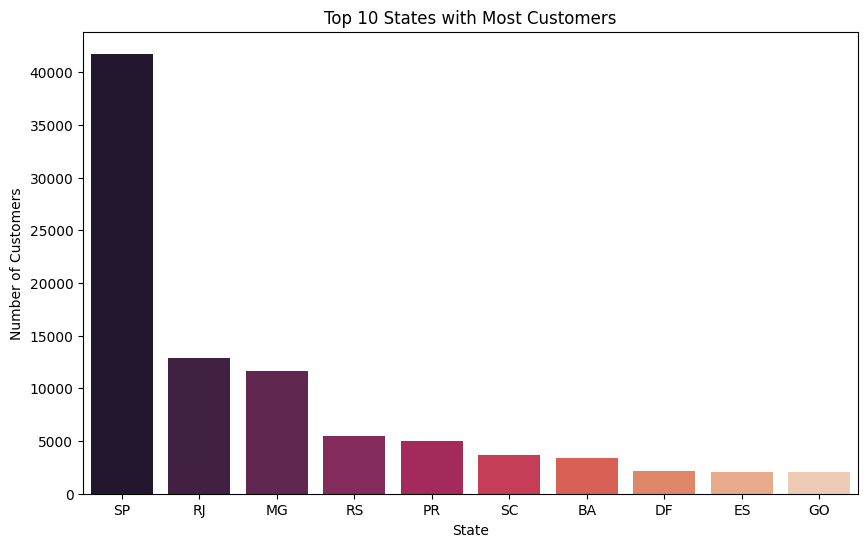

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_customer['customer_state'].value_counts().head(10).index,
            y=df_customer['customer_state'].value_counts().head(10).values, palette='rocket')
plt.title('Top 10 States with Most Customers')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

### 3.2 Products Dataset

In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB



- `df translation`과 left join으로 포르투갈어 카테고리명을 영어로 변환합니다.
- 번역 없는 항목은 Unknown으로 대체합니다.

In [ ]:
df_products_eng = df_products.merge(df_translation, on='product_category_name', how='left')
df_products_eng['product_category_name_english'] = df_products_eng['product_category_name_english'].fillna('Unknown')

In [ ]:
df_products_eng['product_category_name_english'].value_counts()

,count
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
...,...
tablets_printing_image,9
fashion_childrens_clothes,5
home_comfort_2,5


In [ ]:
df_products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
df_products_eng = df_products_eng.dropna(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'])

In [ ]:
df_products_eng.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,1
product_length_cm,1
product_height_cm,1
product_width_cm,1
product_category_name_english,0


/tmp/ipykernel_512/2079311773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


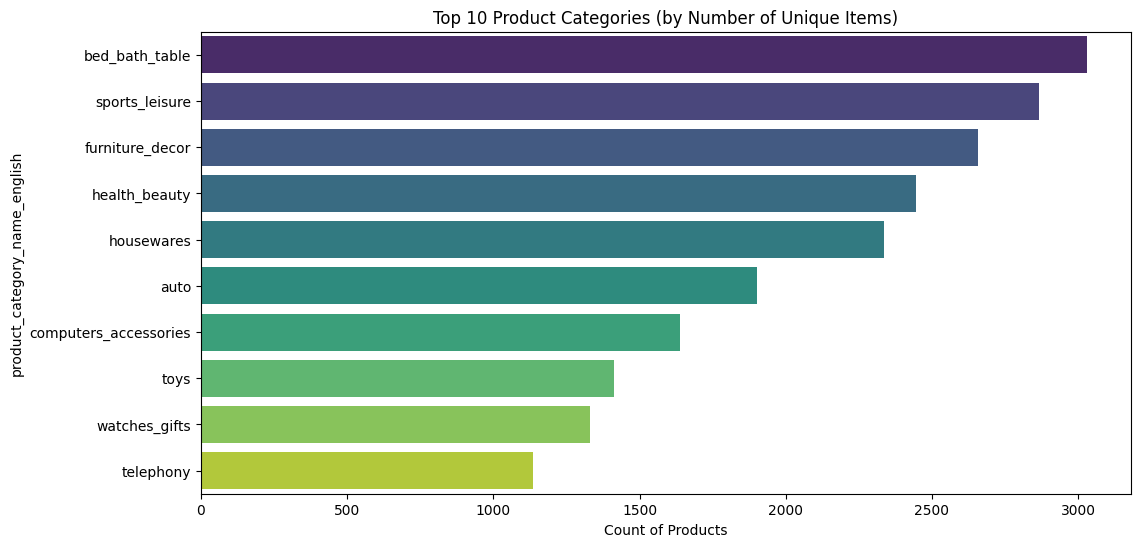

In [ ]:
plt.figure(figsize=(12, 6))



top_categories = df_products_eng['product_category_name_english'].value_counts().head(10)



sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Product Categories (by Number of Unique Items)')
plt.xlabel('Count of Products')
plt.show()

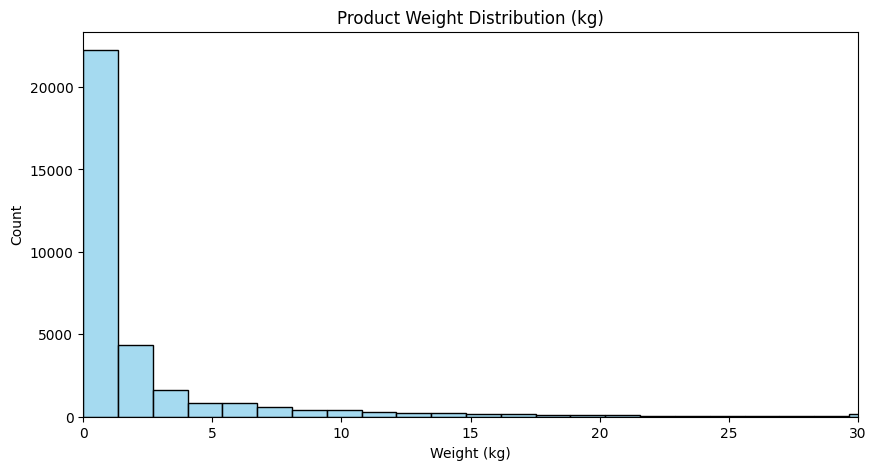

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_products['product_weight_g'] / 1000, bins=30, kde=False, color='skyblue')
plt.title('Product Weight Distribution (kg)')
plt.xlabel('Weight (kg)')
plt.xlim(0, 30)
plt.show()

### 3.3 Sellers Dataset

In [ ]:
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
df_sellers.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
df_de

### 3.4 Order Items Dataset

In [ ]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])

In [ ]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [ ]:
df_order_items['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


🚀 **Task 1**. 운임 비율 (`freight_ratio`)

- 상품 가격에 비해 배송비는 얼마나 클까요? 가격 대비 운임 비율을 계산하세요.

In [ ]:
# Write your code here


### 3.5 Order Payment Dataset

In [ ]:
df_order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
df_order_payment['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


### 3.6 Order Review Dataset

In [ ]:
df_order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


🚀 **Task 2**. 응답 시간 (`response_time`)

- 리뷰 작성 → 판매자 응답까지 걸린 시간을 계산합니다.

In [ ]:
# Write your code here


### 3.7 Orders Dataset

### 3.8 Geolocation Dataset

# 4️⃣ Features Engineering

시간 정보 추출하기

In [ ]:
df_orders['purchase_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.strftime('%Y-%m')
df_orders['purchase_day_of_week'] = df_orders['order_purchase_timestamp'].dt.day_name()

부피 피처 생성하기

In [ ]:
df_products_eng['product_volume_cm3'] = (
    df_products_eng['product_length_cm'] *
    df_products_eng['product_height_cm'] *
    df_products_eng['product_width_cm']
)

🚀 **Task 3**. 배송 지연 여부 (`is_late`)

- 원본 데이터셋만으로는 배송이 실제로 지연되었는지 바로 파악하기 어렵습니다. 배송 지연 여부를 나타내는 컬럼은 어떻게 생성할 수 있을까요?

- 실제 배송에 걸린 기간을 의미하는 `delivery_days` 변수도 함께 생성해 보세요.

In [ ]:
# Write your code here
# 1. is_late


# 2. delivery_days
